# Erasmus Mundus Scholarship Prediction Project

**Life cycle of Machine learning Project**

* Understanding the Problem Statement
* Data Collection
* Exploratory data analysis
* Data Cleaning
* Data Pre-Processing
* Model Training
* Choose best model

---

## About
The Erasmus Mundus Joint Master (EMJM) is a prestigious, integrated, international study programme, jointly delivered by an international consortium of higher education institutions. The scholarship is highly competitive and depends on various criteria including academic records, test scores (GRE, TOEFL, IELTS), work experience, statement of purpose (SOP), letter of recommendation (LOR), and other extracurricular achievements.

## 1) Problem statement.

* Every year, thousands of students apply for the Erasmus Mundus Scholarship, making the selection process highly competitive and rigorous.
* The selection committee needs to review a huge volume of applications. A Machine Learning model can help shortlist highly potential candidates based on historical data.

**In this project we are going to use the data given to build a Classification model:**

* This model is to predict if a student will be awarded the scholarship or not based on the given dataset.
* This can be used to recommend a suitable profile for applicants and help them understand which criteria influence the final decision.

## 2) Data Collection.

* The Dataset is collected from previous applicants' profiles and outcomes.
* The data consists of 1000 Rows and 17 Columns.

In [138]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

warnings.filterwarnings("ignore")

%matplotlib inline

In [139]:
df = pd.read_csv('Graduate.csv')

In [140]:
df.head()

,GRE_Score,TOEFL_Score,IELTS_Score,CGPA,University_Rating,SOP,LOR,Research,Publications,Work_Experience_Months,Internship,Leadership_Score,Awards_Count,Country,Target_Program,Graduation_Year,Scholarship_Awarded
0,295.0,96.0,7.5,2.93,2,4.9,1.7,0,1,8,No,5,0,Nepal,EMJM Cyber,2024,No
1,340.0,119.0,9.0,3.76,3,4.1,1.7,0,1,31,Yes,4,0,Pakistan,EMJM Cyber,2025,No
2,336.0,96.0,7.5,3.12,1,3.2,1.8,1,2,29,Yes,4,1,Bangladesh,EMJM Cyber,2022,No
3,337.0,108.0,8.0,2.11,4,3.4,1.3,0,0,35,Yes,3,0,Bangladesh,EMJM DS,2025,No
4,323.0,98.0,7.5,3.40,1,1.1,1.3,0,1,16,Yes,2,0,India,EMJM DS,2025,No


In [141]:
df.describe()

,GRE_Score,TOEFL_Score,IELTS_Score,CGPA,University_Rating,SOP,LOR,Research,Publications,Work_Experience_Months,Leadership_Score,Awards_Count,Graduation_Year
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,315.840000,106.459000,8.064500,3.027160,3.053000,2.997000,3.014400,0.517000,1.119000,18.814000,4.552000,0.333000,2023.473000
std,15.083432,8.449954,0.557585,0.582774,1.421341,1.163239,1.163136,0.499961,0.908661,8.896097,1.388966,0.475749,1.124516
min,290.000000,92.000000,7.000000,2.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,2022.000000
25%,303.000000,99.000000,7.500000,2.530000,2.000000,2.000000,2.000000,0.000000,0.000000,13.000000,4.000000,0.000000,2022.000000
50%,316.000000,107.000000,8.000000,3.025000,3.000000,3.000000,3.000000,1.000000,1.000000,19.000000,5.000000,0.000000,2023.000000
75%,329.000000,114.000000,8.500000,3.550000,4.000000,4.000000,4.000000,1.000000,2.000000,25.000000,6.000000,1.000000,2024.000000
max,340.000000,120.000000,9.000000,4.000000,5.000000,5.000000,5.000000,1.000000,4.000000,36.000000,8.000000,2.000000,2025.000000


### 3. EXPLORING DATA

In [142]:
# define numerical & categorical columns
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

# print columns
print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 13 numerical features : ['GRE_Score', 'TOEFL_Score', 'IELTS_Score', 'CGPA', 'University_Rating', 'SOP', 'LOR', 'Research', 'Publications', 'Work_Experience_Months', 'Leadership_Score', 'Awards_Count', 'Graduation_Year']

We have 4 categorical features : ['Internship', 'Country', 'Target_Program', 'Scholarship_Awarded']


In [143]:
# proportion of count data on categorical columns
for col in categorical_features:
    print(df[col].value_counts(normalize=True) * 100)
    print('---------------------------')

Internship
Yes    90.0
No     10.0
Name: proportion, dtype: float64
---------------------------
Country
Pakistan      26.3
Bangladesh    26.1
Nepal         24.7
India         22.9
Name: proportion, dtype: float64
---------------------------
Target_Program
EMJM Cyber    34.6
EMJM AI       34.1
EMJM DS       31.3
Name: proportion, dtype: float64
---------------------------
Scholarship_Awarded
No     73.0
Yes    27.0
Name: proportion, dtype: float64
---------------------------


### 📊 Insights from the Data Description:
1. **Dataset Size:** We have data for exactly **1000** applicants.
2. **Missing Values:** The count row shows 1000 for all numerical columns, meaning there are **no missing values** here.
3. **Academic Scores:**
   - **GRE Score:** Ranges from 290 to 340 (Average: 315.84)
   - **TOEFL Score:** Ranges from 92 to 120 (Average: 106.46)
   - **IELTS Score:** Ranges from 7.0 to 9.0 (Average: 8.06)
   - **CGPA:** Ranges from 2.0 to 4.0 (Average: 3.02)
4. **Experience & Research:**
   - **Research Experience:** About 51.7% of the applicants have research experience.
   - **Work Experience:** Applicants have between 0 to 36 months of work experience (Average: ~1.5 years).
5. **Other Metrics:** Leadership scores range from 1 to 8, and awards count up to 2.


## Univariate Analysis

The term univariate analysis refers to the analysis of one variable prefix “uni” means “one.” The purpose of univariate analysis is to understand the distribution of values for a single variable.
Other Type of Analysis are

## Bivariate Analysis: 
The analysis of two variables.

## Multivariate Analysis: 
The analysis of two or more variables.
 

### Numerical Features

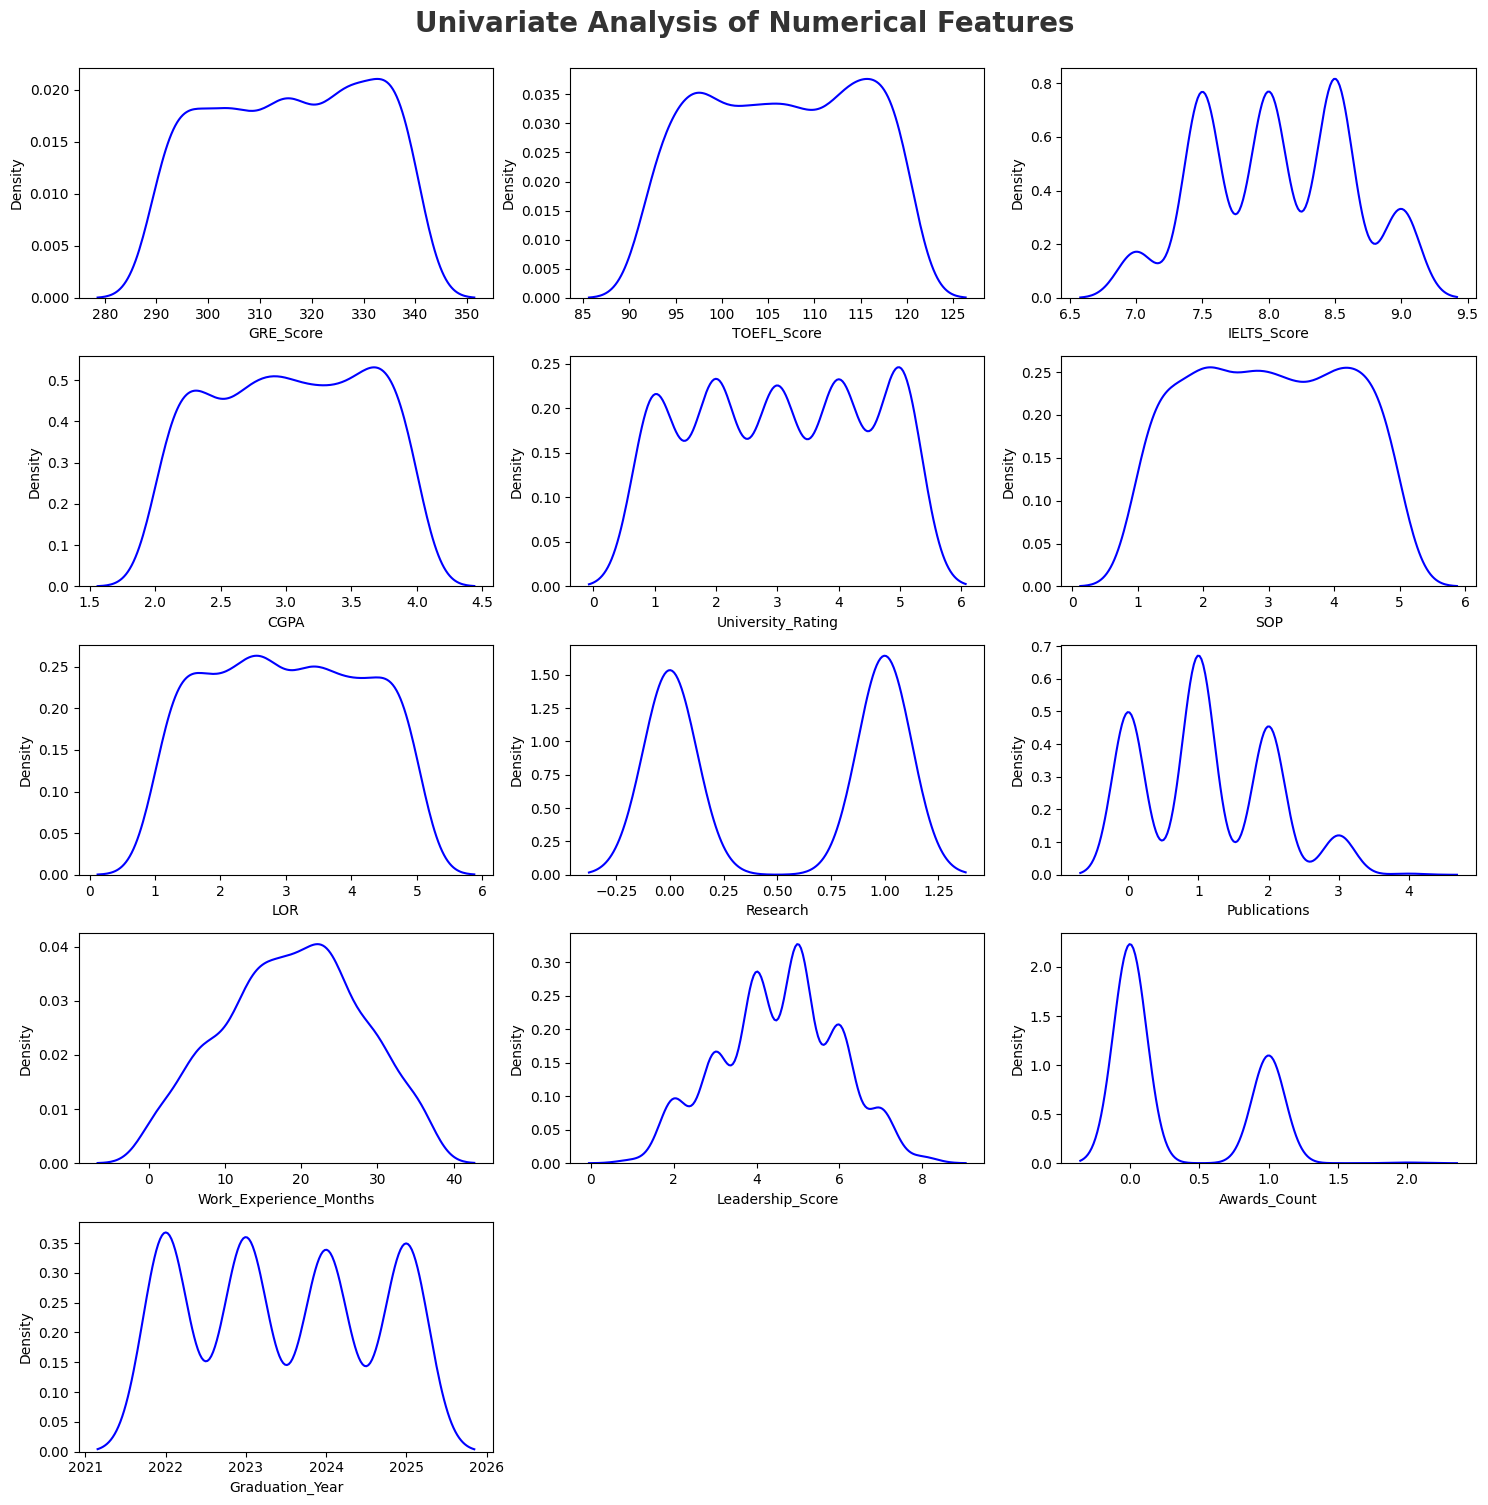

In [144]:
plt.figure(figsize=(15, 15))
plt.suptitle('Univariate Analysis of Numerical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)

for i in range(0, len(numeric_features)):
    plt.subplot(5, 3, i+1)
    sns.kdeplot(x=df[numeric_features[i]], color='blue')
    plt.xlabel(numeric_features[i])
    
plt.tight_layout()

    
# save plot
# plt.savefig('./images/Univariate_Num.png')

### 💡 Insights from Categorical & Univariate Analysis:
1. **Internship:** The vast majority (**90%**) of the applicants have internship experience.
2. **Country Distribution:** The applicants are almost equally distributed among four South Asian countries: **Pakistan (26.3%), Bangladesh (26.1%), Nepal (24.7%), and India (22.9%)**.
3. **Target Program:** The demand is quite balanced across the three programs: **Cyber (34.6%), AI (34.1%), and DS (31.3%)**.
4. **Scholarship Success Rate:** Only **27%** of the applicants were awarded the scholarship, which clearly shows that the EMJM scholarship is highly competitive.
5. **Numerical Distributions:** Most numerical features (like GRE, CGPA, etc.) show specific peak areas (from the KDE plots), helping us understand the average profile of a strong candidate.


### Categorical Features

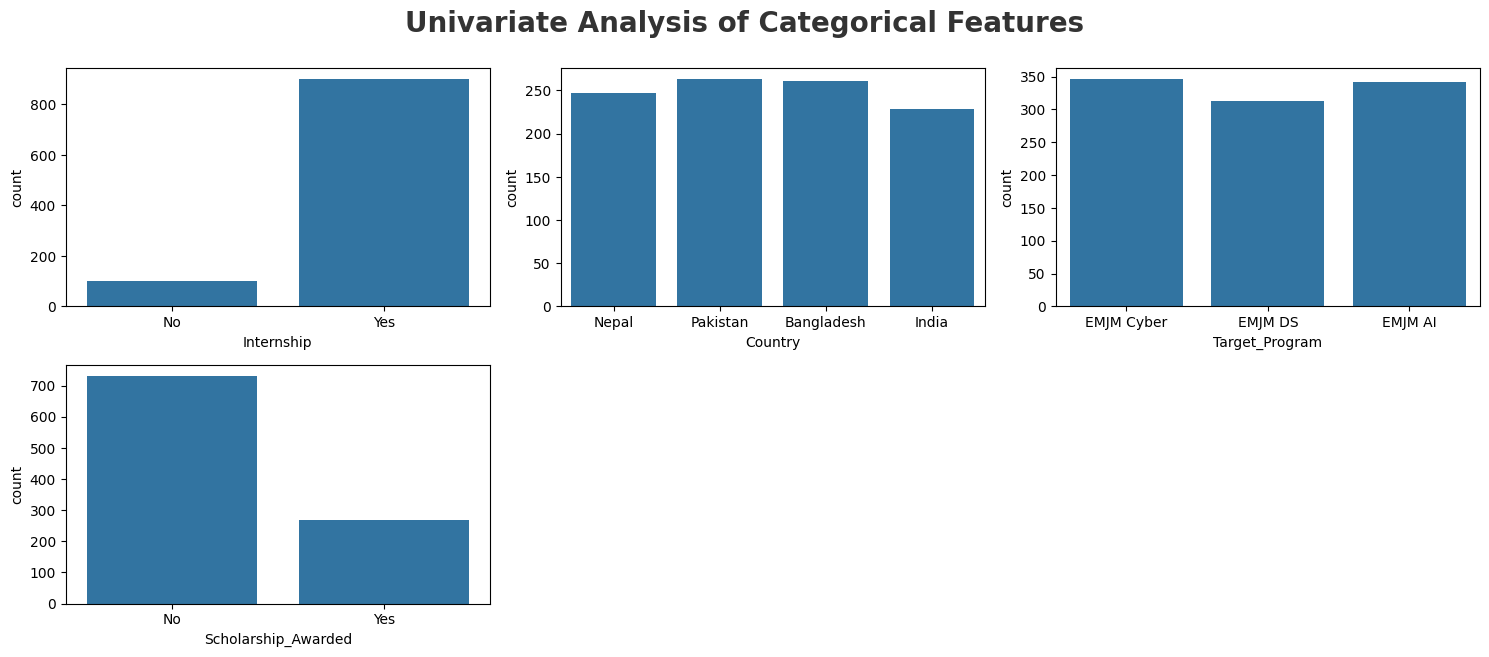

In [145]:
# categorical columns
plt.figure(figsize=(15, 15))
plt.suptitle('Univariate Analysis of Categorical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)

for i in range(0, len(categorical_features)):
    plt.subplot(5, 3, i+1)
    sns.countplot(x=df[categorical_features[i]])
    plt.xlabel(categorical_features[i])
    plt.tight_layout()
    
# save plot


### 💡 Insights from Categorical Countplots:
1. **Internship:** The graph clearly shows that the vast majority (about 90%) of applicants have internship experience.
2. **Country:** The number of applicants is almost equally distributed among four countries: Pakistan, Bangladesh, Nepal, and India.
3. **Target Program:** Student interest is very balanced across the three programs: Cyber, AI, and Data Science (DS), with Cyber having slightly more applicants.
4. **Scholarship Awarded:** The 'No' bar is significantly larger, indicating that most students did not receive the scholarship (only 27% succeeded). This highlights the highly competitive nature of the EMJM scholarship.


### Multivariate Analysis
Multivariate analysis is the analysis of more than one variable.

In [146]:
# Separating numerical features into discrete and continuous
discrete_features = [feature for feature in numeric_features if len(df[feature].unique()) <= 25]
continuous_features = [feature for feature in numeric_features if len(df[feature].unique()) > 25]

print('We have {} discrete features: {}'.format(len(discrete_features), discrete_features))
print('\nWe have {} continuous features: {}'.format(len(continuous_features), continuous_features))


We have 7 discrete features: ['IELTS_Score', 'University_Rating', 'Research', 'Publications', 'Leadership_Score', 'Awards_Count', 'Graduation_Year']

We have 6 continuous features: ['GRE_Score', 'TOEFL_Score', 'CGPA', 'SOP', 'LOR', 'Work_Experience_Months']


### Outlier Detection in Continuous Features
We use boxplots to identify if there are any outliers in our continuous data.


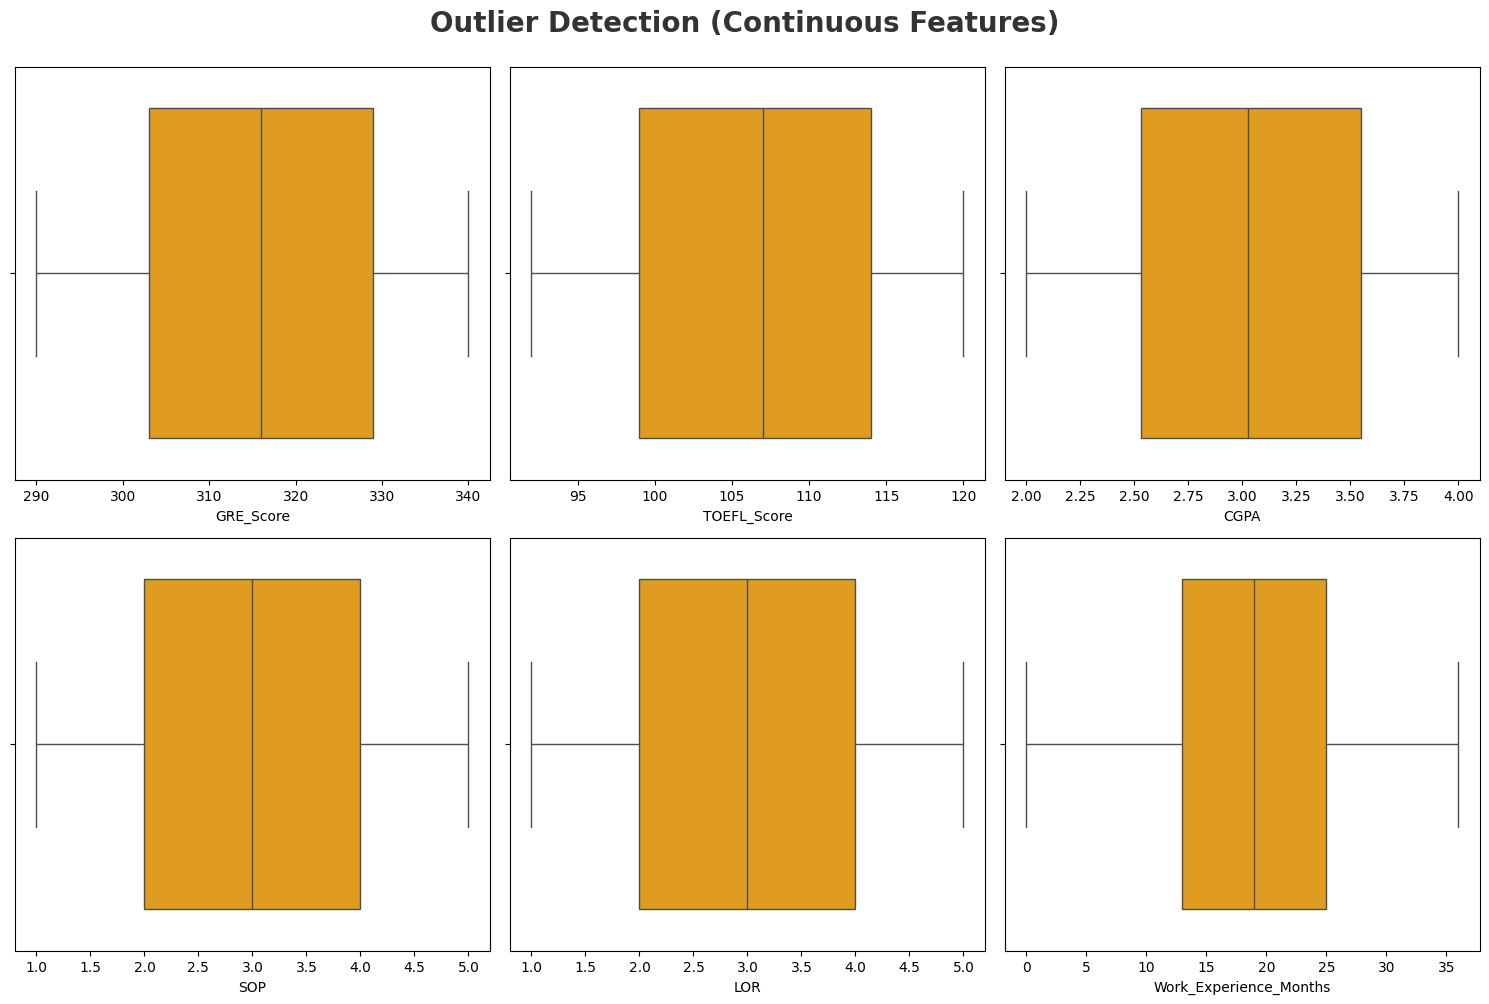

In [147]:
plt.figure(figsize=(15, 10))
plt.suptitle('Outlier Detection (Continuous Features)', fontsize=20, fontweight='bold', alpha=0.8, y=1.)

for i in range(0, len(continuous_features)):
    plt.subplot(2, 3, i+1)
    sns.boxplot(x=df[continuous_features[i]], color='orange')
    plt.xlabel(continuous_features[i])

plt.tight_layout()


### Distribution of Discrete Features
We use countplots to see the frequency of each unique value in our discrete features.


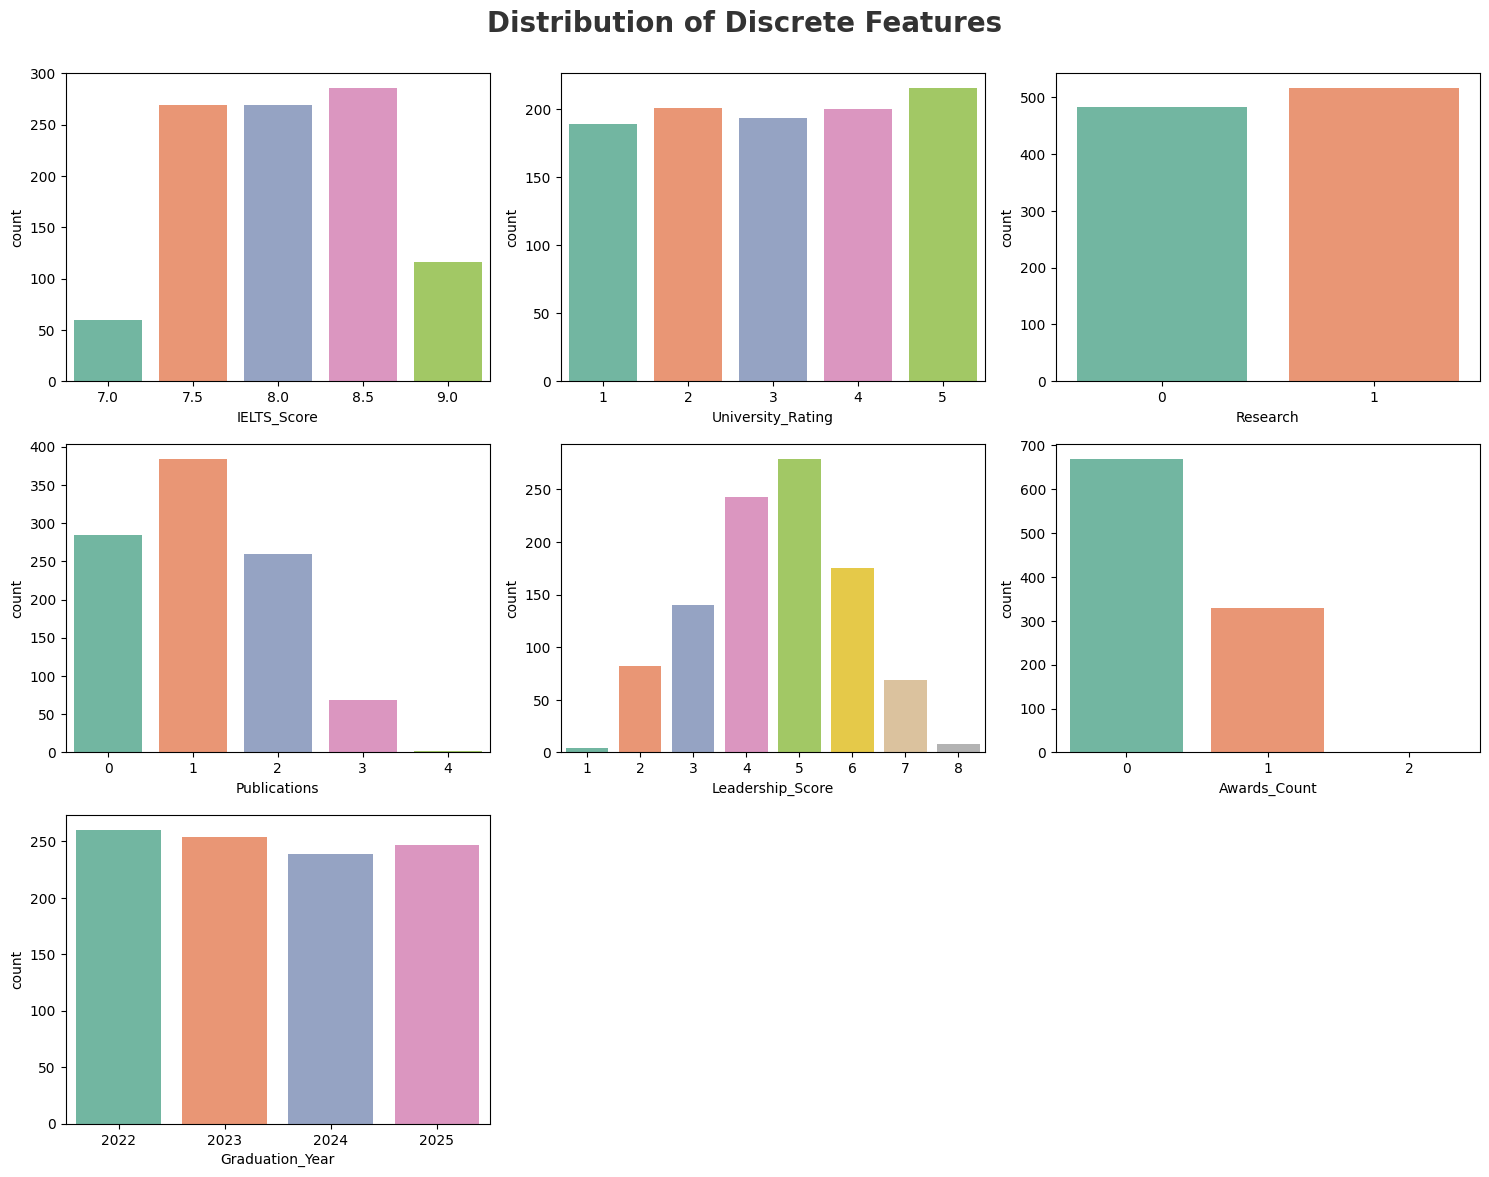

In [148]:
plt.figure(figsize=(15, 15))
plt.suptitle('Distribution of Discrete Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)

for i in range(0, len(discrete_features)):
    plt.subplot(4, 3, i+1)
    sns.countplot(x=df[discrete_features[i]], palette='Set2')
    plt.xlabel(discrete_features[i])

plt.tight_layout()


### 💡 Insights from Boxplots and Countplots:

**1. Continuous Features (Boxplots):**
- **NO OUTLIERS!** The boxplots clearly show that there are **0 outliers** across all continuous features (GRE, TOEFL, CGPA, Work Experience, etc.). This indicates that the dataset is extremely clean and well-distributed. You will not need to do any outlier treatment (like clipping or dropping data) in the data preprocessing stage!

**2. Discrete Features (Countplots):**
- **High Academic Standards:** The most frequent IELTS score is an impressive **8.5**, and the most frequent University Rating is **5** (top-rated).
- **Research & Publications:** The majority of the applicants have Research experience (1) and at least **1 Publication**.
- **Extracurriculars:** Most students have a Leadership Score of **5**, but the most frequent count for extra Awards is **0**, meaning having an award could be a strong distinguishing factor for getting the scholarship.
- **Demographics:** The highest number of applicants graduated in **2022**, the most targeted program is **EMJM Cyber**, and the highest applicant count is from **Pakistan**.


##  Check Multicollinearity in Numerical features

In [149]:
df.head()

,GRE_Score,TOEFL_Score,IELTS_Score,CGPA,University_Rating,SOP,LOR,Research,Publications,Work_Experience_Months,Internship,Leadership_Score,Awards_Count,Country,Target_Program,Graduation_Year,Scholarship_Awarded
0,295.0,96.0,7.5,2.93,2,4.9,1.7,0,1,8,No,5,0,Nepal,EMJM Cyber,2024,No
1,340.0,119.0,9.0,3.76,3,4.1,1.7,0,1,31,Yes,4,0,Pakistan,EMJM Cyber,2025,No
2,336.0,96.0,7.5,3.12,1,3.2,1.8,1,2,29,Yes,4,1,Bangladesh,EMJM Cyber,2022,No
3,337.0,108.0,8.0,2.11,4,3.4,1.3,0,0,35,Yes,3,0,Bangladesh,EMJM DS,2025,No
4,323.0,98.0,7.5,3.40,1,1.1,1.3,0,1,16,Yes,2,0,India,EMJM DS,2025,No


## Check Multicollinearity for Categorical features
A chi-squared test (also chi-square or χ2 test) is a statistical hypothesis test that is valid to perform when the test statistic is chi-squared distributed under the null hypothesis, specifically Pearson's chi-squared test

A chi-square statistic is one way to show a relationship between two categorical variables.

Here we test correlation of Categorical columns with Target column i.e case_status

Null Hypothesis (
): The Feature is independent of target column (No-Correlation)

Alternative Hypothesis (
): The Feature and Target column are not independent (Correalted)

In [ ]:
from scipy.stats import chi2_contingency

chi2_test = []

 
cat_features_for_test = [f for f in categorical_features if f != 'Scholarship_Awarded']

for feature in cat_features_for_test:
     
    p_value = chi2_contingency(pd.crosstab(df['Scholarship_Awarded'], df[feature]))[1]
    
    if p_value < 0.05:
        chi2_test.append('Reject Null Hypothesis')
    else:
        chi2_test.append('Fail to Reject Null Hypothesis')
        
result = pd.DataFrame(data=[cat_features_for_test, chi2_test]).T
result.columns = ['Column', 'Hypothesis Result']
result


,Column,Hypothesis Result
0,Internship,Reject Null Hypothesis
1,Country,Fail to Reject Null Hypothesis
2,Target_Program,Fail to Reject Null Hypothesis


### 💡 Insights from Multicollinearity and Chi-Square Test:

**1. Multicollinearity (Correlation Heatmap):**
- Checking the correlation heatmap among numerical features, we look for values >= 0.8 or <= -0.8.
- If there are highly correlated features, it means they provide redundant information, and we might need to drop one of them before training our machine learning model to prevent multicollinearity issues.

**2. Chi-Square Test (Categorical Features):**
- **Internship (Reject Null Hypothesis):** This means there is a statistically significant relationship between having an internship and getting the scholarship. It is a highly important feature for our model.
- **Country & Target_Program (Fail to Reject):** This means the selection process has no bias towards any specific country (Bangladesh, India, Nepal, Pakistan) or any specific program (AI, Cyber, DS). The EMJM scholarship is awarded purely based on merit and applicant profile, making these features statistically less important for the model.
